# Mobility Pathways Results Viewer
## Transferable lab analysis notebook

This notebook visualizes any master scenario dataset generated by `Scenarios_Definition_Levers_ASI_from_Toolkit_Inputs.ipynb`.

It is based on `Results_Cloud_Analysis.ipynb`, but parameterized so the same analysis works for Gipuzkoa, Boston, or another lab defined in `Toolkit_Mobility_Pathways_Inputs.xlsx`.


In [33]:
# Setup and imports
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

print(f"numpy      {np.__version__}")
print(f"pandas     {pd.__version__}")
print(f"matplotlib {matplotlib.__version__}")

numpy      2.4.4
pandas     3.0.2
matplotlib 3.10.8


## 1. Configuration

Change only this cell for a different lab. If `PARQUET_PATH = None`, the notebook searches for common output names from the scenario-builder notebook.


In [34]:
# ---------------------------------------------------------------------------
# User configuration
# ---------------------------------------------------------------------------
INPUT_XLSX = Path("Toolkit_Mobility_Pathways_Inputs.xlsx")
LAB_ID = "GIP"   # examples: "GIP", "BOS"

# Leave as None to auto-detect, or set explicitly, e.g.:
# PARQUET_PATH = Path("scenarios_master_boston.parquet")
PARQUET_PATH = None

# ---------------------------------------------------------------------------
# Manual emissions-share inputs for budget ceilings
# ---------------------------------------------------------------------------
# Option A, recommended when you know both shares:
#   passenger_transport_share = TRANSPORT_EMISSIONS_SHARE * PASSENGER_WITHIN_TRANSPORT_SHARE
# Use fractions, not percentages: 0.25 = 25%.
TRANSPORT_EMISSIONS_SHARE_OVERRIDE = None
PASSENGER_TRANSPORT_WITHIN_TRANSPORT_SHARE_OVERRIDE = None

# Option B, use this if you already know the final passenger-transport share
# over total emissions. This overrides Option A and the macro sheet.
# Example: 0.08 means passenger transport is 8% of total emissions.
PASSENGER_TRANSPORT_EMISSIONS_SHARE_OVERRIDE = 0.48 * 0.461

# If all three values above are None, the notebook tries to read the two share
# columns from the macro sheet in Toolkit_Mobility_Pathways_Inputs.xlsx.

# Carbon-budget method.
WORLD_POPULATION = 8.2e9
ANNUAL_GLOBAL_EMISSIONS_GT = 35
YEARS_ALREADY_EMITTED = 5
IPCC_BUDGETS_GT = {
    "1.5C": 500,
    "1.7C": 850,
    "2.0C": 1350,
}

GRID_EFFORT = {
    "STEPS": 0.00,
    "APS": 0.50,
    "NZE": 1.00,
}

OUT_DIR = Path("results_viewer_outputs") / LAB_ID.lower()
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("Lab:", LAB_ID)
print("Output directory:", OUT_DIR.resolve())

Lab: GIP
Output directory: /Users/joanpau/Desktop/Toolkit/TEST RESULTADOS /results_viewer_outputs/gip


## 2. Load Lab Metadata and Dataset

Lab name and population are read from the toolkit workbook. The Parquet is the output from the scenario-builder notebook.


In [35]:
def _find_col(columns, *needles):
    for col in columns:
        norm = str(col).lower().replace("\n", " ")
        if all(n.lower() in norm for n in needles):
            return col
    raise KeyError(f"Could not find column containing: {needles}")


def _slug(text):
    return re.sub(r"[^a-z0-9]+", "_", str(text).strip().lower()).strip("_")


def _load_lab_metadata(input_xlsx, lab_id):
    config = pd.read_excel(input_xlsx, sheet_name="CONFIG", header=1)
    macro = pd.read_excel(input_xlsx, sheet_name="macro", header=1)

    cfg_lab_col = _find_col(config.columns, "lab")
    cfg_id_col = _find_col(config.columns, "short unique id")
    region_col = _find_col(config.columns, "region")

    macro_id_col = _find_col(macro.columns, "lab id")
    pop_col = _find_col(macro.columns, "population")
    year_col = _find_col(macro.columns, "year")
    transport_share_col = _find_col(macro.columns, "transport represents")
    passenger_transport_share_col = _find_col(macro.columns, "passenger transport represents")

    cfg = config[config[cfg_id_col] == lab_id]
    mac = macro[macro[macro_id_col] == lab_id]
    if cfg.empty:
        raise ValueError(f"No CONFIG row found for LAB_ID={lab_id!r}")
    if mac.empty:
        raise ValueError(f"No macro row found for LAB_ID={lab_id!r}")

    cfg = cfg.iloc[0]
    mac = mac.sort_values(year_col).iloc[0]
    region = str(cfg[region_col])
    lab_name = f"{cfg[cfg_lab_col]} — {region}"
    pop = int(round(float(mac[pop_col])))
    base_year = int(round(float(mac[year_col])))
    transport_share = mac[transport_share_col]
    passenger_transport_share = mac[passenger_transport_share_col]
    region_slug = _slug(region)
    region_short_slug = region_slug.split("_")[0] if region_slug else ""
    return lab_name, pop, base_year, region_slug, region_short_slug, transport_share, passenger_transport_share


def _resolve_parquet_path(lab_id, explicit_path=None, extra_slugs=None):
    if explicit_path is not None:
        path = Path(explicit_path)
        if not path.exists():
            raise FileNotFoundError(f"Configured PARQUET_PATH does not exist: {path}")
        return path

    slug = _slug(lab_id)
    all_slugs = [slug]
    for extra in extra_slugs or []:
        if extra and extra not in all_slugs:
            all_slugs.append(extra)

    candidates = []
    for s in all_slugs:
        candidates.extend([
            Path(f"scenarios_master_{s}.parquet"),
            Path(f"scenarios_master_toolkit_{s}.parquet"),
        ])
    candidates.extend([
        Path(f"scenarios_master_{lab_id}.parquet"),
        Path(f"scenarios_master_toolkit_{lab_id}.parquet"),
    ])
    if lab_id.upper() == "GIP":
        candidates.extend([Path("scenarios_master_toolkit.parquet"), Path("scenarios_master.parquet")])

    for path in candidates:
        if path.exists():
            return path

    msg = "\n".join(f"  - {p}" for p in candidates)
    raise FileNotFoundError(
        f"No scenario Parquet found for LAB_ID={lab_id!r}.\n"
        "Run the scenario-builder notebook first, or set PARQUET_PATH explicitly.\n"
        f"Checked:\n{msg}"
    )


def _as_fraction(value):
    if pd.isna(value):
        return np.nan
    value = float(value)
    return value / 100.0 if value > 1.0 else value


def _resolve_passenger_transport_share(
    transport_share,
    passenger_transport_share,
    direct_override,
    transport_share_override,
    passenger_transport_share_override,
):
    if direct_override is not None:
        share = _as_fraction(direct_override)
        source = "direct passenger-transport share override"
    else:
        if transport_share_override is not None:
            transport_share = transport_share_override
            transport_source = "configuration override"
        else:
            transport_source = "macro sheet"

        if passenger_transport_share_override is not None:
            passenger_transport_share = passenger_transport_share_override
            passenger_source = "configuration override"
        else:
            passenger_source = "macro sheet"

        transport_share = _as_fraction(transport_share)
        passenger_transport_share = _as_fraction(passenger_transport_share)
        if np.isfinite(transport_share) and np.isfinite(passenger_transport_share):
            share = transport_share * passenger_transport_share
            source = (
                "transport share * passenger-within-transport share "
                f"({transport_source} * {passenger_source})"
            )
        else:
            raise ValueError(
                "Passenger-transport emissions share is missing. In the first configuration cell, set either "
                "PASSENGER_TRANSPORT_EMISSIONS_SHARE_OVERRIDE directly, or set both "
                "TRANSPORT_EMISSIONS_SHARE_OVERRIDE and "
                "PASSENGER_TRANSPORT_WITHIN_TRANSPORT_SHARE_OVERRIDE. Alternatively fill the two macro columns."
            )
    if not (0.0 <= share <= 1.0):
        raise ValueError(f"Passenger-transport emissions share must be between 0 and 1. Got {share}.")
    return share, source


def _compute_budget_ceilings(ipcc_budgets_gt, passenger_share):
    rows = []
    ceilings = {}
    for label, total_gt in ipcc_budgets_gt.items():
        remaining_gt = total_gt - YEARS_ALREADY_EMITTED * ANNUAL_GLOBAL_EMISSIONS_GT
        ceiling = remaining_gt * passenger_share * 1e9 / WORLD_POPULATION
        ceilings[label] = float(ceiling)
        rows.append({
            "Climate target": label,
            "IPCC budget [GtCO2]": total_gt,
            "Already emitted subtraction [GtCO2]": YEARS_ALREADY_EMITTED * ANNUAL_GLOBAL_EMISSIONS_GT,
            "Remaining global budget [GtCO2]": remaining_gt,
            "Passenger transport share": passenger_share,
            "Budget ceiling [tCO2eq/cap]": ceiling,
        })
    return ceilings, pd.DataFrame(rows)


(
    LAB_NAME,
    POP,
    BASE_YEAR,
    REGION_SLUG,
    REGION_SHORT_SLUG,
    TRANSPORT_EMISSIONS_SHARE_RAW,
    PASSENGER_TRANSPORT_SHARE_RAW,
) = _load_lab_metadata(INPUT_XLSX, LAB_ID)

PASSENGER_TRANSPORT_EMISSIONS_SHARE, SHARE_SOURCE = _resolve_passenger_transport_share(
    TRANSPORT_EMISSIONS_SHARE_RAW,
    PASSENGER_TRANSPORT_SHARE_RAW,
    PASSENGER_TRANSPORT_EMISSIONS_SHARE_OVERRIDE,
    TRANSPORT_EMISSIONS_SHARE_OVERRIDE,
    PASSENGER_TRANSPORT_WITHIN_TRANSPORT_SHARE_OVERRIDE,
)
BUDGET_CEILINGS, budget_table = _compute_budget_ceilings(IPCC_BUDGETS_GT, PASSENGER_TRANSPORT_EMISSIONS_SHARE)
BUDGET_15C_WORLD = BUDGET_CEILINGS["1.5C"]
BUDGET_17C_WORLD = BUDGET_CEILINGS["1.7C"]
BUDGET_20C_WORLD = BUDGET_CEILINGS["2.0C"]

PARQUET_PATH = _resolve_parquet_path(
    LAB_ID,
    PARQUET_PATH,
    extra_slugs=[REGION_SLUG, REGION_SHORT_SLUG],
)

print("Lab name:", LAB_NAME)
print("Population:", f"{POP:,}")
print("Base year:", BASE_YEAR)
print("Parquet:", PARQUET_PATH.resolve())
print("Passenger transport emissions share:", f"{PASSENGER_TRANSPORT_EMISSIONS_SHARE:.2%}", f"({SHARE_SOURCE})")
display(budget_table)

Lab name: CSL Gipuzkoa — Gipuzkoa (Basque Country)
Population: 735,332
Base year: 2025
Parquet: /Users/joanpau/Desktop/Toolkit/TEST RESULTADOS /scenarios_master_toolkit.parquet
Passenger transport emissions share: 22.13% (direct passenger-transport share override)


,Climate target,IPCC budget [GtCO2],Already emitted subtraction [GtCO2],Remaining global budget [GtCO2],Passenger transport share,Budget ceiling [tCO2eq/cap]
0,1.5C,500,175,325,0.22128,8.770244
1,1.7C,850,175,675,0.22128,18.215122
2,2.0C,1350,175,1175,0.22128,31.707805


In [36]:
df = pd.read_parquet(PARQUET_PATH)

year_cols = sorted([c for c in df.columns if c.startswith("per_cap_")], key=lambda c: int(c.split("_")[-1]))
lever_cols = ["L1_EV", "L2_modal", "L3_demand", "L_Embodied", "Grid"]
required_cols = set(lever_cols + year_cols)
missing = sorted(required_cols - set(df.columns))
if missing:
    raise ValueError(f"Parquet is missing required columns: {missing}")

YEARS = [int(c.split("_")[-1]) for c in year_cols]
print(f"{'Scenarios loaded':<30} {len(df):>12,}")
print(f"{'Columns':<30} {len(df.columns):>12,}")
print(f"{'Memory (MB)':<30} {df.memory_usage(deep=True).sum()/1e6:>12.1f}")
print(f"Year columns: {year_cols[0]} ... {year_cols[-1]} ({len(year_cols)} years)")
print(f"Lever columns: {lever_cols}")

df[lever_cols].describe(include="all").T

Scenarios loaded                  1,350,723
Columns                                  32
Memory (MB)                           168.8
Year columns: per_cap_2025 ... per_cap_2050 (26 years)
Lever columns: ['L1_EV', 'L2_modal', 'L3_demand', 'L_Embodied', 'Grid']


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
L1_EV,1350723.0,NaN,NaN,NaN,0.5,0.316228,0.0,0.2,0.5,0.8,1.0
L2_modal,1350723.0,NaN,NaN,NaN,0.03,0.017607,0.0,0.015,0.03,0.045,0.06
L3_demand,1350723.0,NaN,NaN,NaN,-0.03,0.017607,-0.06,-0.045,-0.03,-0.015,0.0
L_Embodied,1350723.0,NaN,NaN,NaN,0.5,0.316228,0.0,0.2,0.5,0.8,1.0
Grid,1350723,3,STEPS,450241,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Feature Engineering

Adds cumulative per-capita emissions, a normalized policy-effort index, and budget tiers.


In [37]:
df = df.copy()
df["cum_per_cap"] = df[year_cols].sum(axis=1)

mapped_grid = pd.to_numeric(df["Grid"].map(GRID_EFFORT), errors="coerce")
if mapped_grid.isna().any():
    unknown = sorted(df.loc[mapped_grid.isna(), "Grid"].astype(str).unique())
    raise ValueError(f"GRID_EFFORT is missing entries for: {unknown}")

df["effort"] = (
    df["L1_EV"]
    + df["L2_modal"] / 0.06
    + df["L3_demand"].abs() / 0.06
    + df["L_Embodied"]
    + mapped_grid
)

# Budget tier: 0 = exceeds 2.0C, 1 = within 2.0C, 2 = within 1.7C, 3 = within 1.5C.
df["tier"] = 0
df.loc[df["cum_per_cap"] <= BUDGET_20C_WORLD, "tier"] = 1
df.loc[df["cum_per_cap"] <= BUDGET_17C_WORLD, "tier"] = 2
df.loc[df["cum_per_cap"] <= BUDGET_15C_WORLD, "tier"] = 3

print("Columns added: cum_per_cap | effort | tier")
df[["cum_per_cap", "effort", "tier"]].describe().round(3)

Columns added: cum_per_cap | effort | tier


,cum_per_cap,effort,tier
count,1350723.000,1350723.000,1350723.000
mean,12.992,2.500,1.974
std,2.540,0.734,0.224
min,7.461,0.000,1.000
25%,11.115,1.983,2.000
50%,12.609,2.500,2.000
75%,14.513,3.017,2.000
max,24.886,5.000,3.000


## 4. Summary Statistics


In [38]:
n_total = len(df)
n_15c = int((df["tier"] == 3).sum())
n_17c = int((df["tier"] >= 2).sum())
n_20c = int((df["tier"] >= 1).sum())
n_over = int((df["tier"] == 0).sum())

baseline = df[
    (df["L1_EV"] == 0.0)
    & (df["L2_modal"] == 0.0)
    & (df["L3_demand"] == 0.0)
    & (df["L_Embodied"] == 0.0)
    & (df["Grid"].astype(str) == "STEPS")
].iloc[0]

print("=" * 64)
print(f"  Lab: {LAB_NAME}")
print("=" * 64)
print(f"{'Total scenarios modelled':<38} {n_total:>12,}")
print(f"{'Within 1.5 C budget':<38} {n_15c:>12,}  ({n_15c/n_total:.1%})")
print(f"{'Within 1.7 C budget':<38} {n_17c:>12,}  ({n_17c/n_total:.1%})")
print(f"{'Within 2.0 C budget':<38} {n_20c:>12,}  ({n_20c/n_total:.1%})")
print(f"{'Exceeds 2.0 C budget':<38} {n_over:>12,}  ({n_over/n_total:.1%})")
print()
print(f"{'Emission range':<38} {df['cum_per_cap'].min():.2f} - {df['cum_per_cap'].max():.2f} tCO2eq/cap")
print(f"{'Baseline cum per-cap':<38} {baseline['cum_per_cap']:.2f} tCO2eq/cap")
print(f"{'Baseline cum absolute':<38} {baseline['cum_tCO2eq_total']/1e6:.2f} MtCO2eq")
print(f"{'1.5 C budget ceiling':<38} {BUDGET_15C_WORLD:.2f} tCO2eq/cap")
print(f"{'1.7 C budget ceiling':<38} {BUDGET_17C_WORLD:.2f} tCO2eq/cap")
print(f"{'2.0 C budget ceiling':<38} {BUDGET_20C_WORLD:.2f} tCO2eq/cap")
print()
if n_15c > 0:
    me = df.loc[df["tier"] == 3, "effort"].min()
    print(f"Minimum effort to reach 1.5 C: {me:.2f} / 5.00")
else:
    print("No scenarios found within the 1.5 C budget.")

  Lab: CSL Gipuzkoa — Gipuzkoa (Basque Country)
Total scenarios modelled                  1,350,723
Within 1.5 C budget                          16,637  (1.2%)
Within 1.7 C budget                       1,298,813  (96.2%)
Within 2.0 C budget                       1,350,723  (100.0%)
Exceeds 2.0 C budget                              0  (0.0%)

Emission range                         7.46 - 24.89 tCO2eq/cap
Baseline cum per-cap                   24.89 tCO2eq/cap
Baseline cum absolute                  18.30 MtCO2eq
1.5 C budget ceiling                   8.77 tCO2eq/cap
1.7 C budget ceiling                   18.22 tCO2eq/cap
2.0 C budget ceiling                   31.71 tCO2eq/cap

Minimum effort to reach 1.5 C: 3.10 / 5.00


## 5. Pareto Cloud

Policy effort is plotted against cumulative per-capita transport emissions. All summary statistics use the full dataset; the plot samples points for rendering speed.


Saved: results_viewer_outputs/gip/pareto_cloud_gip.png


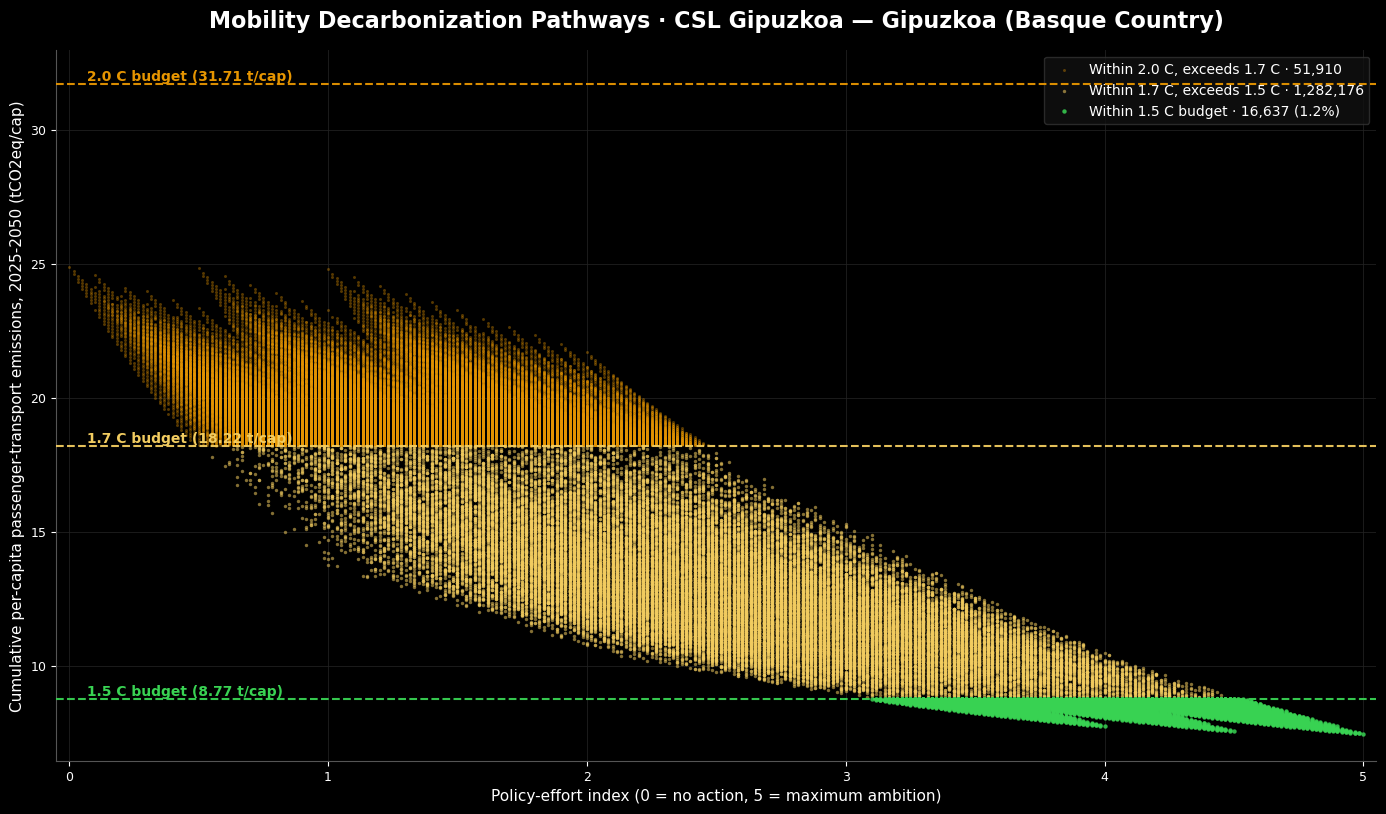

In [39]:
DARK_BG = "#000000"
FORE_COL = "#ffffff"
RED_COL = "#E64646"
ORANGE_COL = "#E69500"
YELLOW_COL = "#F2CC60"
GREEN_COL = "#39D353"


def plot_pareto_cloud(df, budget_15c, budget_17c, budget_20c, lab_name, save_path=None, max_sample_by_tier=None):
    if max_sample_by_tier is None:
        max_sample_by_tier = {0: 80_000, 1: 50_000, 2: 50_000, 3: 50_000}

    tier = df["tier"].to_numpy()
    eff = df["effort"].to_numpy()
    emi = df["cum_per_cap"].to_numpy()
    n_t = len(df)
    n_15 = int((tier == 3).sum())
    n_17 = int((tier >= 2).sum())
    n_20 = int((tier >= 1).sum())
    n_ov = int((tier == 0).sum())

    fig, ax = plt.subplots(figsize=(15, 9), facecolor=DARK_BG)
    ax.set_facecolor(DARK_BG)
    fig.subplots_adjust(left=0.08, right=0.96, top=0.90, bottom=0.11)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_color("#555555")
    ax.spines["left"].set_color("#555555")
    ax.tick_params(colors=FORE_COL)
    ax.grid(True, color="#222222", linewidth=0.7, alpha=0.8)

    cfgs = {
        0: dict(c=RED_COL, alpha=0.12, s=2.5, label=f"Exceeds 2.0 C budget · {n_ov:,}"),
        1: dict(c=ORANGE_COL, alpha=0.38, s=4.5, label=f"Within 2.0 C, exceeds 1.7 C · {n_20 - n_17:,}"),
        2: dict(c=YELLOW_COL, alpha=0.55, s=6.0, label=f"Within 1.7 C, exceeds 1.5 C · {n_17 - n_15:,}"),
        3: dict(c=GREEN_COL, alpha=0.85, s=10.0, label=f"Within 1.5 C budget · {n_15:,} ({n_15/n_t:.1%})"),
    }

    rng = np.random.default_rng(42)
    for k, cfg in cfgs.items():
        idx = np.where(tier == k)[0]
        if len(idx) == 0:
            continue
        cap = max_sample_by_tier.get(k, len(idx))
        if len(idx) > cap:
            idx = rng.choice(idx, size=cap, replace=False)
        ax.scatter(eff[idx], emi[idx], linewidths=0, zorder=k + 1, **cfg)

    budget_lines = [
        (budget_20c, ORANGE_COL, "2.0 C budget"),
        (budget_17c, YELLOW_COL, "1.7 C budget"),
        (budget_15c, GREEN_COL, "1.5 C budget"),
    ]
    for y, color, label in budget_lines:
        ax.axhline(y, color=color, linestyle="--", linewidth=1.5, alpha=0.95, zorder=20)
        ax.text(0.05, y, f" {label} ({y:.2f} t/cap)", color=color, va="bottom", fontsize=10, fontweight="bold")

    ax.set_xlim(-0.05, 5.05)
    y_low = max(0, min(emi.min(), budget_15c) - 1)
    y_high = max(emi.max(), budget_20c) * 1.04
    ax.set_ylim(y_low, y_high)

    ax.set_xlabel("Policy-effort index (0 = no action, 5 = maximum ambition)", color=FORE_COL)
    ax.set_ylabel("Cumulative per-capita passenger-transport emissions, 2025-2050 (tCO2eq/cap)", color=FORE_COL)
    ax.set_title(f"Mobility Decarbonization Pathways · {lab_name}", color=FORE_COL, fontsize=16, fontweight="bold", pad=16)

    leg = ax.legend(loc="upper right", frameon=True, facecolor="#111111", edgecolor="#333333", fontsize=10)
    for txt in leg.get_texts():
        txt.set_color(FORE_COL)

    if save_path is not None:
        fig.savefig(save_path, dpi=220, bbox_inches="tight", facecolor=fig.get_facecolor())
        print(f"Saved: {save_path}")
    return fig


fig = plot_pareto_cloud(
    df,
    budget_15c=BUDGET_15C_WORLD,
    budget_17c=BUDGET_17C_WORLD,
    budget_20c=BUDGET_20C_WORLD,
    lab_name=LAB_NAME,
    save_path=OUT_DIR / f"pareto_cloud_{LAB_ID.lower()}.png",
)
plt.show()

## 7. Export Feasible Pathways

Exports ranked feasible scenarios for the selected lab.


In [40]:
feasible = (
    df[df["tier"] == 3][[
        "L1_EV", "L2_modal", "L3_demand", "L_Embodied", "Grid",
        "cum_per_cap", "effort", "cum_tCO2eq_total",
    ]]
    .sort_values(["effort", "cum_per_cap"])
    .reset_index(drop=True)
)

feasible_renamed = feasible.rename(columns={
    "L1_EV": "EV target (L1)",
    "L2_modal": "Modal shift rate (L2)",
    "L3_demand": "Demand reduction (L3)",
    "L_Embodied": "Embodied emission cut (LEm)",
    "Grid": "Grid pathway",
    "cum_per_cap": "Cum. per-cap [tCO2eq]",
    "effort": "Effort index (0-5)",
    "cum_tCO2eq_total": "Cum. absolute [tCO2eq]",
})

out_csv = OUT_DIR / f"feasible_1p5c_{LAB_ID.lower()}.csv"
feasible_renamed.to_csv(out_csv, index=False)
print(f"Exported {len(feasible_renamed):,} feasible 1.5 C scenarios -> {out_csv}")

if len(feasible_renamed):
    display(
        feasible_renamed.head(10).style.format({
            "EV target (L1)": "{:.0%}",
            "Modal shift rate (L2)": "{:.2%}",
            "Demand reduction (L3)": "{:.2%}",
            "Embodied emission cut (LEm)": "{:.0%}",
            "Cum. per-cap [tCO2eq]": "{:.2f}",
            "Effort index (0-5)": "{:.2f}",
            "Cum. absolute [tCO2eq]": "{:,.0f}",
        })
    )
else:
    print("No 1.5 C feasible scenarios under the selected budget.")

Exported 16,637 feasible 1.5 C scenarios -> results_viewer_outputs/gip/feasible_1p5c_gip.csv


,EV target (L1),Modal shift rate (L2),Demand reduction (L3),Embodied emission cut (LEm),Grid pathway,Cum. per-cap [tCO2eq],Effort index (0-5),Cum. absolute [tCO2eq]
0,100%,0.60%,-6.00%,100%,STEPS,8.76,3.10,"6,439,403"
1,100%,0.70%,-6.00%,100%,STEPS,8.73,3.12,"6,422,462"
2,100%,1.30%,-6.00%,90%,STEPS,8.76,3.12,"6,441,082"
3,100%,0.80%,-5.90%,100%,STEPS,8.76,3.12,"6,441,928"
4,100%,0.80%,-6.00%,100%,STEPS,8.71,3.13,"6,405,664"
5,100%,1.40%,-6.00%,90%,STEPS,8.74,3.13,"6,424,722"
6,100%,0.90%,-5.90%,100%,STEPS,8.74,3.13,"6,425,018"
7,100%,1.00%,-5.80%,100%,STEPS,8.76,3.13,"6,444,387"
8,100%,1.50%,-5.90%,90%,STEPS,8.76,3.13,"6,444,413"
9,100%,2.00%,-6.00%,80%,STEPS,8.76,3.13,"6,444,222"
